# Pitch Tracking
This is the raw pitch and error data streamed from the tuner while a single `E2` string is plucked. Harmonic errors are inherent in pitch detection and, in this auto-tuner system, can cause the motor to chase spurious deviations and oscillate. These harmonic errors must be stabilised.

The spikes in the traces indicate harmonics. The following develops a method to detect and correct them, achieving stable pitch and error tracking.

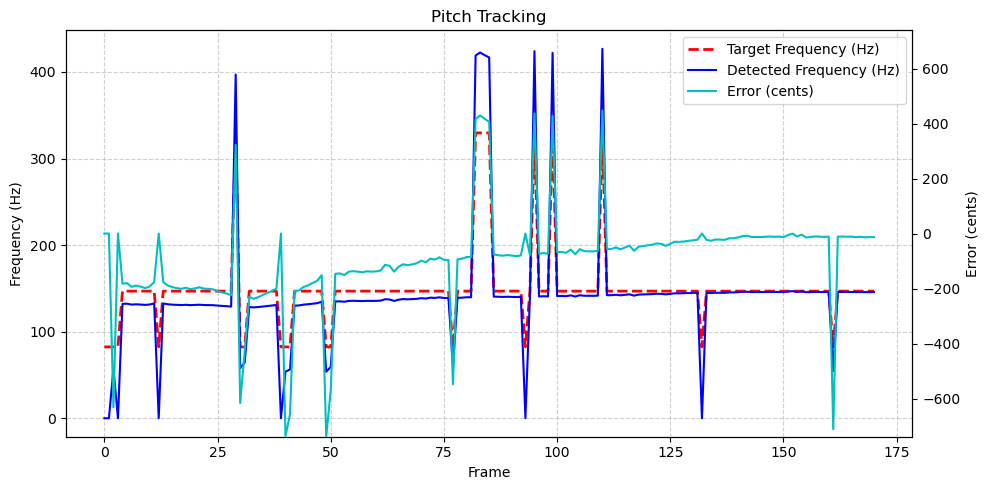

In [ ]:
from data.error_stream import (steady_E2_error, 
                               steady_E2_freq, 
                               steady_E2_trgt,
                               tuning_D4_error,
                               tuning_D4_detected, 
                              tuning_D4_trgt )
import matplotlib.pyplot as plt

error_cents = tuning_D4_error
target_freq = tuning_D4_trgt
detected_freq = tuning_D4_detected

fig, ax1 = plt.subplots(figsize=(10, 5))

# Left axis: frequencies
ax1.plot(target_freq, "r--", linewidth=2, label="Target Frequency (Hz)")
ax1.plot(detected_freq, "b", label="Detected Frequency (Hz)")
ax1.set_xlabel("Frame")
ax1.set_ylabel("Frequency (Hz)")
ax1.grid(True, linestyle="--", alpha=0.6)


ax2 = ax1.twinx()
ax2.plot(error_cents, "c", label="Error (cents)")
ax2.set_ylabel("Error (cents)")


ymax = max(abs(min(error_cents)), abs(max(error_cents)))
ax2.set_ylim(-ymax, ymax)

# Combine legends
lines = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper right")

plt.title("Pitch Tracking")
plt.tight_layout()
plt.show()

## Stabilising the target 
`error_cents` is calculated relative to the current string, chosen as the string that minimises the error. When a harmonic is misdetected, the target can jump to a different string, which confuses the error calculation. By keeping the last $5$ target frequencies and applying a median filter, these spurious jumps are suppressed.

A target is chosen every $128\,\text{ms}$ frame. By keeping the last $5$ frames, the system is protected against wrong string detections for up to $640\,\text{ms}$. This window is short enough that a real string change is not perceived as lag, yet long enough to suppress brief spurious spikes in string detection. The target frequency buffer can also be flushed whenever the noise gate detects silence.

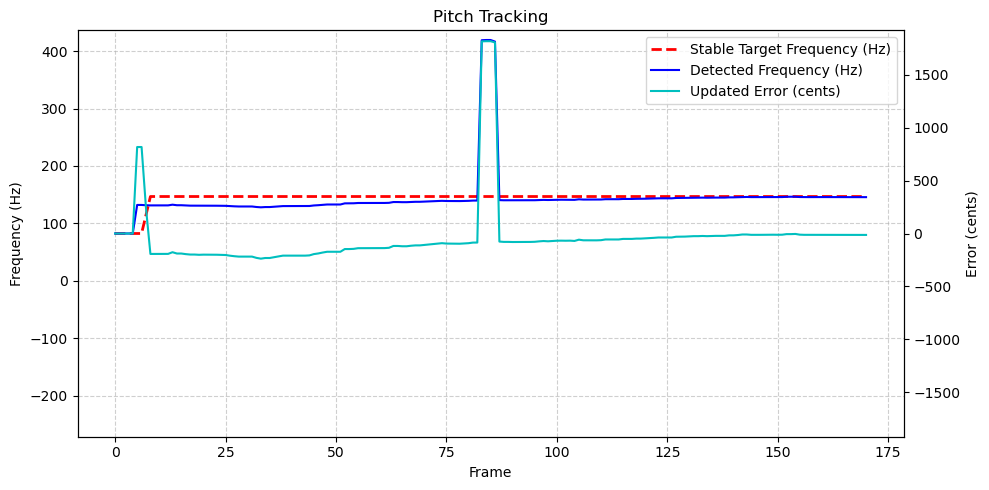

In [ ]:
from collections import deque
import statistics
import math
import matplotlib.pyplot as plt

def get_error_in_cents(detected_freq, target_freq):
    if detected_freq <= 0.0 or target_freq <= 0.0:
        return 0.0
    return 1200.0 * math.log2(detected_freq / target_freq)

stabilised_targets = []
stabilised_detected = []
fifo_trgt = deque(maxlen=10)
fifo_det = deque(maxlen=3)
for target, detected in zip(target_freq, detected_freq):
   
    if detected <= 60:
        detected = stabilised_detected[-1] if stabilised_detected else target

  
    err = get_error_in_cents(detected, target)


    if abs(err) > 1000:
        detected = stabilised_detected[-1] if stabilised_detected else target

    fifo_trgt.append(target)
    fifo_det.append(detected)
    stable_target = statistics.median(fifo_trgt)
    stable_detected = statistics.median(fifo_det)
    stabilised_targets.append(stable_target)
    stabilised_detected.append(stable_detected)

# Recalculate error
updated_error_cents = []
for target_f, f in zip(stabilised_targets, stabilised_detected):
    updated_error_cents.append(get_error_in_cents(f, target_f))

# ---------------- plotting ----------------
fig, ax1 = plt.subplots(figsize=(10, 5))

# Left axis (Hz)
ax1.plot(stabilised_targets,"r--",linewidth=2 ,label="Stable Target Frequency (Hz)")
ax1.plot(stabilised_detected,"b", label="Detected Frequency (Hz)")
ax1.set_xlabel("Frame")
ax1.set_ylabel("Frequency (Hz)")

# Symmetric about 82.41
center = 82.35
ymin, ymax = ax1.get_ylim()
span = max(center - ymin, ymax - center)
ax1.set_ylim(center - span, center + span)

# Right axis (cents)
ax2 = ax1.twinx()
ax2.plot(updated_error_cents, "c", label="Updated Error (cents)")
ax2.set_ylabel("Error (cents)")

# Symmetric about 0
ymin, ymax = ax2.get_ylim()
span = max(abs(ymin), abs(ymax))
ax2.set_ylim(-span, span)

# Combine legends
lines = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper right")

plt.title("Pitch Tracking")
ax1.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## Kalman Filter

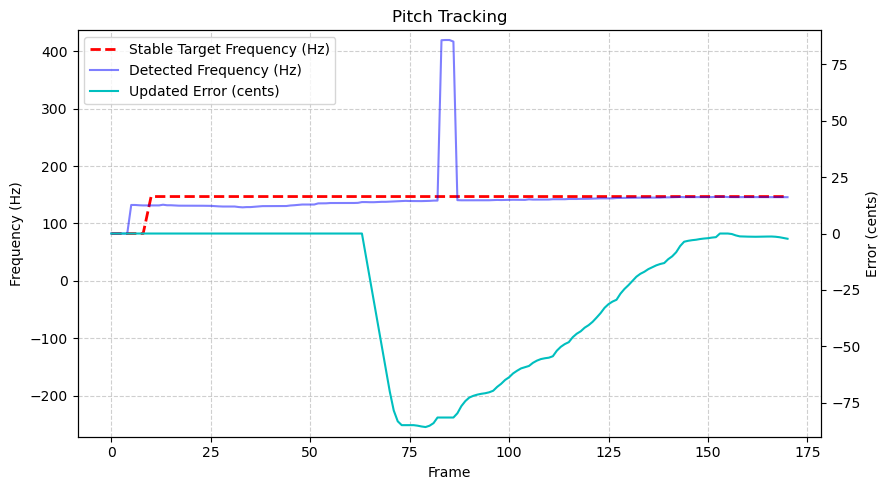

In [ ]:
import math
from collections import deque
import matplotlib.pyplot as plt

# ---------- inputs ----------
ft_stream = stabilised_targets        
fd_stream = stabilised_detected     

# ---------- knobs ----------
DT            = 0.128
ABS_GATE      = 400.0          # reject if |z| > 400¢
INNOV_GATE    = 120.0          # reject if |z - e_hat| > 120¢
ALPHA         = 0.30           # EMA smoothing (0.15–0.30)
DEADBAND      = 3.0            # ± cents
SLEW_PER_FR   = 10.0            # max change per frame in cents
SILENCE_HZ    = 20.0            # treat fd < SILENCE_HZ as “no note”
RESET_ON_SIL  = True

# ---------- helpers ----------
def cents_from(fd, ft):
    if fd <= 0.0 or ft <= 0.0:
        return None
    return 1200.0 * math.log2(fd / ft)

def ema(prev, meas, alpha):
    return prev + alpha * (meas - prev)

def deadband_sticky(x, db):
    if abs(x) <= db: return 0.0
    return math.copysign(abs(x) - db, x)

def fold_octaves(fd, fref):
    """Fold fd to the nearest octave of fref (cheap harmonic rejection)."""
    if fd <= 0.0 or fref <= 0.0: return fd
    r = fd / fref
    m = round(math.log2(r))       
    return fd / (2.0 ** m)

# ---------- state ----------
target_fifo_trgt = deque(maxlen=5)  
z_buf       = deque(maxlen=3) 
stable_target_hz   = []
stable_error_cents = []
e_hat = 0.0
in_silence = True


for ft_raw, fd_raw in zip(ft_stream, fd_stream):


    if fd_raw <= SILENCE_HZ or ft_raw <= 0.0:

        if RESET_ON_SIL and not in_silence:
            target_fifo_trgt.clear()
            z_buf.clear()
            e_hat = 0.0
            in_silence = True
        stable_target_hz.append(ft_raw if ft_raw > 0 else 0.0)
        stable_error_cents.append(e_hat)
        continue
    in_silence = False

    # 1) Stable target (median-of-5)
    target_fifo_trgt.append(ft_raw)
    ft = sorted(target_fifo_trgt)[len(target_fifo_trgt)//2]
    stable_target_hz.append(ft)

    # 2) Fold obvious octaves BEFORE computing cents
    fd = fold_octaves(fd_raw, ft)

    # 3) Measurement in cents
    z = cents_from(fd, ft)
    if z is None:
        stable_error_cents.append(e_hat)
        continue

    # 4) Hard gates (stricter)
    if abs(z) > ABS_GATE:
        stable_error_cents.append(e_hat)
        continue
    if abs(z - e_hat) > INNOV_GATE:
        stable_error_cents.append(e_hat)
        continue

    # 5) Median-of-3 on cents
    z_buf.append(z)
    z_med = sorted(z_buf)[len(z_buf)//2]

    # 6) EMA
    e_raw = ema(e_hat, z_med, ALPHA)

    # 7) Deadband
    e_db = deadband_sticky(e_raw, DEADBAND)

    # 8) Slew-limit
    delta = max(-SLEW_PER_FR, min(SLEW_PER_FR, e_db - e_hat))
    e_hat = e_hat + delta

    stable_error_cents.append(e_hat)

# ---------- plot ----------
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(stable_target_hz, 'r--', lw=2, label='Stable Target Frequency (Hz)')
ax1.plot(fd_stream, 'b', alpha=0.5, label='Detected Frequency (Hz)')
ax1.set_xlabel('Frame'); ax1.set_ylabel('Frequency (Hz)')
ax1.grid(True, ls='--', alpha=0.6)

ax2 = ax1.twinx()
ax2.plot(stable_error_cents, 'c', label='Updated Error (cents)')
ax2.set_ylabel('Error (cents)')

lines = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')
plt.title('Pitch Tracking')

center = 82.41
ymin, ymax = ax1.get_ylim()
span = max(center - ymin, ymax - center)   
ax1.set_ylim(center - span, center + span)
ymin, ymax = ax2.get_ylim()
limit = max(abs(ymin), abs(ymax))
ax2.set_ylim(-limit, limit)
plt.tight_layout()
plt.show()